In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI&ML/Hotel_Reviews.csv')

In [ ]:
print("Columns:")
print(df.columns)

Columns:
Index(['Review', 'Rating'], dtype='object')


In [ ]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Review    0
Rating    0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [ ]:
#uppercase letters check
uppercase_count = df['Review'].str.contains(r'[A-Z]', na=False).sum()

print(f"Number of rows with uppercase letters: {uppercase_count}")

Number of rows with uppercase letters: 0


Text Preprocessing, Tokenization, & Sequence Padding

In [ ]:
print("\nOriginal Rating Distribution:")
print(df['Rating'].value_counts())


Original Rating Distribution:
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


In [ ]:
# Map ratings (1 to 5) directly to class labels (0 to 4)
df['Label'] = df['Rating'].astype(int) - 1
print("\nOriginal Rating Distribution (Actual target counts):")
print(df['Rating'].value_counts().sort_index())
print("\nMapped 5-Class Distribution (Labels 0-4):")
print(df['Label'].value_counts().sort_index())


Original Rating Distribution (Actual target counts):
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Mapped 5-Class Distribution (Labels 0-4):
Label
0    1421
1    1793
2    2184
3    6039
4    9054
Name: count, dtype: int64


In [ ]:
# df['Sentiment'] = df['Rating'].apply(lambda score: 1 if score > 3 else 0)

# print("\nMapped Sentiment Class Distribution:")
# print(df['Sentiment'].value_counts(normalize=True) * 100)


Mapped Sentiment Class Distribution:
Sentiment
1    73.656727
0    26.343273
Name: proportion, dtype: float64


Text Processing Pipeline

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
!pip install contractions
import contractions
import re

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

#preserving negation words
stop_words = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'but', 'however', 'none'}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def clean_text_pipeline(raw_text):
  if not isinstance(raw_text, str):
    return ""

  text = raw_text
  text = raw_text.lower()
  #expanding contractions
  text = contractions.fix(text)

  #URLs strip
  text = re.sub(r'https?://\S+|www\.\S+', '', text)

  #mentions and hashtags strip
  text = re.sub(r'@\w+|#\w+', '', text)

  #numbers, punctuation, and special symbols strip
  text = re.sub(r'[^a-z\s]', '', text)

  #whitespaces
  tokens = text.split()

  #stop words and execute lemmatization
  cleaned_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]

  return " ".join(cleaned_tokens)

print("Preprocessing reviews...")
df['Cleaned_Review'] = df['Review'].apply(clean_text_pipeline)
print("Text cleaning complete.")

Preprocessing reviews...
Text cleaning complete.


In [ ]:
#before and after
print("\n" + "="*40 + "\nBEFORE/AFTER PREPROCESSING EXAMPLES\n" + "="*40)
for i in range(2):
  print(f"Sample {i+1} [RAW]: {df['Review'].iloc[i][:150]}...")
  print(f"Sample {i+1} [CLEANED]: {df['Cleaned_Review'].iloc[i][:150]}\n" + "-"*40)


BEFORE/AFTER PREPROCESSING EXAMPLES
Sample 1 [RAW]: nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick ea...
Sample 1 [CLEANED]: nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy litt
----------------------------------------
Sample 2 [RAW]: ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, su...
Sample 2 [CLEANED]: ok nothing special charge diamond member hilton decided chain shot th anniversary seattle start booked suite paid extra website description not suite 
----------------------------------------


Exploratory Data Analysis (EDA)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

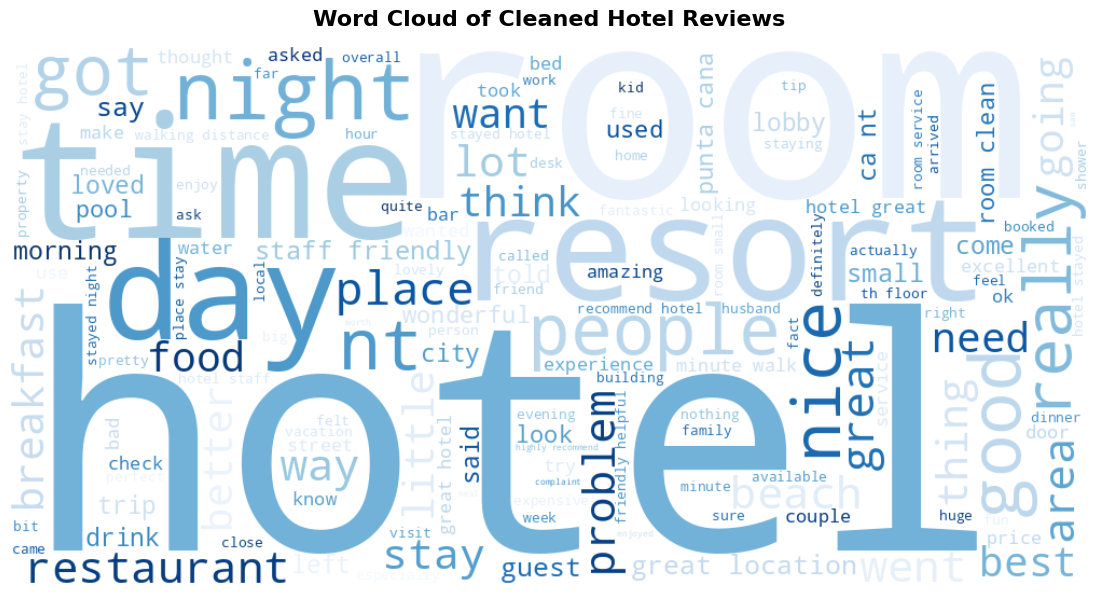

In [ ]:
corpus_text = " ".join(df['Cleaned_Review'])

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=150, colormap='Blues').generate(corpus_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Hotel Reviews', fontsize=16, fontweight='bold', pad=15)
plt.show()

/tmp/ipykernel_13497/1893427313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='viridis')


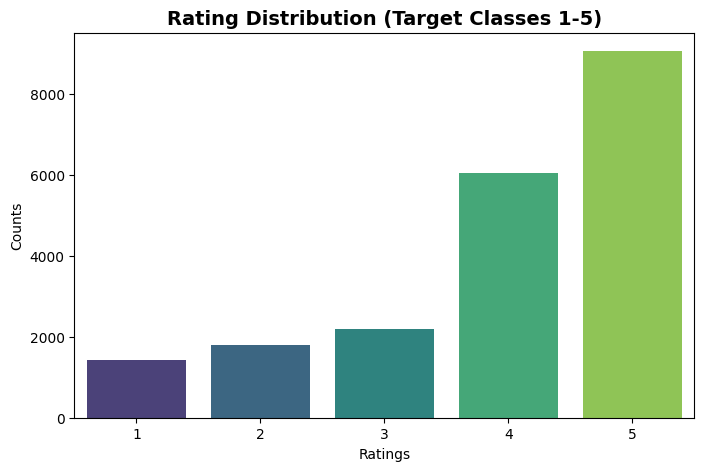

In [ ]:
#Rating Class Countplot
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Rating Distribution (Target Classes 1-5)', fontsize=14, fontweight='bold')
plt.xlabel('Ratings')
plt.ylabel('Counts')
plt.show()

**Train-Test Splitting**

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
df['Review'],
df['Label'],
test_size=0.20,
stratify=df['Label'],
random_state=42
)

X_train_clean = df['Cleaned_Review'].loc[X_train_orig.index]
X_test_clean = df['Cleaned_Review'].loc[X_test_orig.index]

Tokenizer fit

In [ ]:
MAX_WORDS = 15000  #vocabulary limit

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
print(f"Calculated effective vocabulary size: {vocab_size}")

Calculated effective vocabulary size: 15000


Padding

In [ ]:
#compute sequence lengths for 95 percentile padding
sequence_lengths = [len(seq) for seq in X_train_seq]
p95_length = int(np.percentile(sequence_lengths, 95))

print(f"Selected Max Length (95th Percentile): {p95_length} tokens")

Selected Max Length (95th Percentile): 263 tokens


pre and post padding and truncating?

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_sequence_len = p95_length

#pre padding to prevent LSTM from diluting
X_train_padded = pad_sequences(X_train_seq,
                               maxlen=max_sequence_len,
                               padding='pre',
                               truncating='pre')

X_test_padded = pad_sequences(X_test_seq,
                              maxlen=max_sequence_len,
                              padding='pre',
                              truncating='pre')

print(f"Train Tensor Matrix shape: {X_train_padded.shape}")
print(f"Test Tensor Matrix shape: {X_test_padded.shape}")

Train Tensor Matrix shape: (16392, 263)
Test Tensor Matrix shape: (4099, 263)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#balanced weights for the 5 classes
balanced_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(balanced_weights))
print("Calculated multi-class weights:", class_weight_dict)

#callback
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
    ]

Calculated multi-class weights: {0: np.float64(2.883377308707124), 1: np.float64(2.2861924686192467), 2: np.float64(1.876588437321122), 3: np.float64(0.6786172635065204), 4: np.float64(0.45263012563854754)}


SImple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import tensorflow as tf

In [ ]:
EMBEDDING_DIM = 100
num_classes = 5

In [ ]:
model_RNN = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              input_length=max_sequence_len,
              mask_zero=True,
              name='embedding_m1'),

    SimpleRNN(units=64,
              dropout=0.2,
              name='simplernn_layer'),

    Dense(units=num_classes,
          activation='softmax',
          name='output_layer')

], name="Model1_RNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM

In [ ]:
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_LSTM = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              input_length=max_sequence_len,
              mask_zero=True,
              name='embedding_m2'),

    LSTM(units=64,
         dropout=0.2,
         name='lstm_layer_m2'),

    Dense(units=num_classes, activation='softmax', name='output_layer')

], name="Model2_LSTM")

Model Training

In [ ]:
epochs = 15
batch_size = 64

In [ ]:
print("Simple RNN Training Starting")
history_RNN = model_RNN.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.10,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model_rnn'),
    verbose=1
)

Simple RNN Training Starting...
Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 47s 193ms/step - accuracy: 0.3517 - loss: 1.5147 - val_accuracy: 0.4628 - val_loss: 1.2893
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 46s 197ms/step - accuracy: 0.4816 - loss: 1.3319 - val_accuracy: 0.4787 - val_loss: 1.2302
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 39s 169ms/step - accuracy: 0.6226 - loss: 0.9880 - val_accuracy: 0.5293 - val_loss: 1.0497
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 44s 180ms/step - accuracy: 0.7554 - loss: 0.5716 - val_accuracy: 0.5512 - val_loss: 1.0362
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 41s 178ms/step - accuracy: 0.8434 - loss: 0.3225 - val_accuracy: 0.5756 - val_loss: 1.0327
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 80s 170ms/step - accuracy: 0.9102 - loss: 0.1932 - val_accuracy: 0.5409 - val_loss: 1.1785
Epoch 7/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9561 - loss: 0.1118 - val_accuracy: 0.5451 - val_loss: 1.2705
Epoch 8/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 40s 172ms/s

In [ ]:
model_RNN.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=["accuracy"]
)

In [ ]:
print("LSTM training")

history_LSTM = model_LSTM.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.10,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model_lstm'),
    verbose=1
)

LSTM training
Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 111s 466ms/step - accuracy: 0.4616 - loss: 1.3483 - val_accuracy: 0.5470 - val_loss: 1.0144
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 108s 467ms/step - accuracy: 0.5582 - loss: 1.0134 - val_accuracy: 0.5701 - val_loss: 0.9393
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 108s 468ms/step - accuracy: 0.6455 - loss: 0.8116 - val_accuracy: 0.5841 - val_loss: 0.9247
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 141s 462ms/step - accuracy: 0.6891 - loss: 0.6851 - val_accuracy: 0.5963 - val_loss: 0.9147
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 106s 458ms/step - accuracy: 0.7345 - loss: 0.5646 - val_accuracy: 0.5341 - val_loss: 1.0407
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 143s 466ms/step - accuracy: 0.7545 - loss: 0.4990 - val_accuracy: 0.5506 - val_loss: 1.0813
Epoch 7/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 108s 466ms/step - accuracy: 0.7902 - loss: 0.4166 - val_accuracy: 0.5524 - val_loss: 1.1423
Epoch 7: early stopping
Restoring model weights from the end o

In [ ]:
model_LSTM.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=["accuracy"]
)

Plotting RNN and LSTM

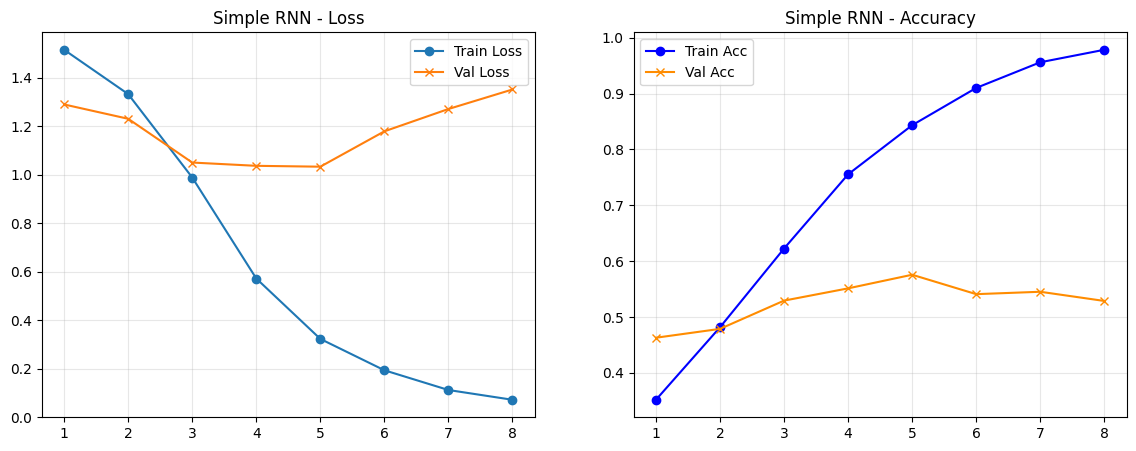

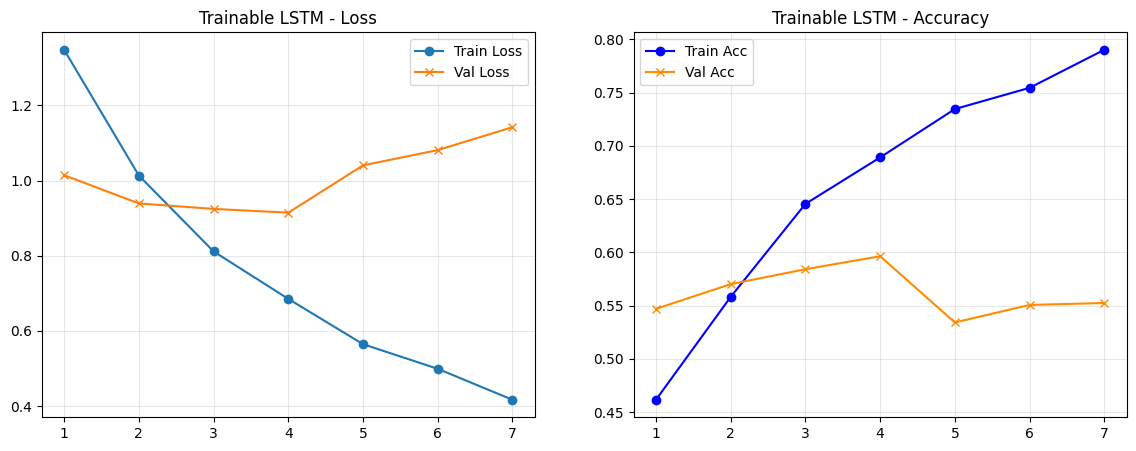

In [ ]:
def curves(history, title):
    epochs_range = range(1, len(history.history['loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, history.history['loss'], label='Train Loss', marker='o')
    ax1.plot(epochs_range, history.history['val_loss'], label='Val Loss', marker='x')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, history.history['accuracy'], label='Train Acc', marker='o', color='blue')
    ax2.plot(epochs_range, history.history['val_accuracy'], label='Val Acc', marker='x', color='darkorange')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.show()

curves(history_RNN, "Simple RNN")
curves(history_LSTM, "Trainable LSTM")

 Evaluate RNN

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step

 EVALUATION: Simple RNN
Test Accuracy: 0.5462

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.47      0.48      0.47       284
     2 Stars       0.35      0.37      0.36       359
     3 Stars       0.30      0.30      0.30       437
     4 Stars       0.46      0.34      0.40      1208
     5 Stars       0.68      0.79      0.73      1811

    accuracy                           0.55      4099
   macro avg       0.45      0.46      0.45      4099
weighted avg       0.53      0.55      0.53      4099



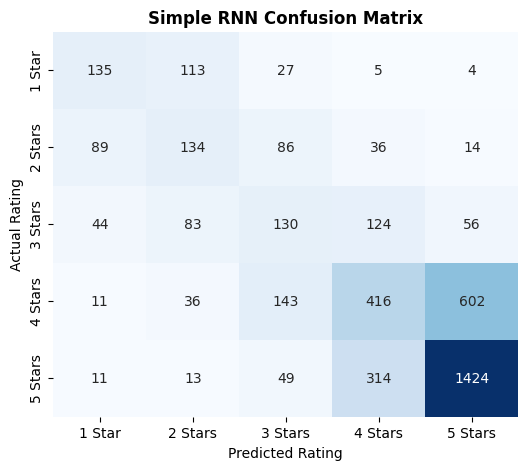

In [ ]:
target_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

# Store test accuracy and run evaluations for Simple RNN
rnn_probs = model_RNN.predict(X_test_padded)
rnn_preds = np.argmax(rnn_probs, axis=1)
acc_rnn = accuracy_score(y_test, rnn_preds)

print("\n" + "="*60 + "\n EVALUATION: Simple RNN\n" + "="*60)
print(f"Test Accuracy: {acc_rnn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rnn_preds, target_names=target_labels))

#Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, rnn_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_labels, yticklabels=target_labels, cbar=False)
plt.title('Simple RNN Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Rating')
plt.xlabel('Predicted Rating')
plt.show()

Evaluate LSTM

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step

 EVALUATION: Trainable LSTM
Test Accuracy: 0.5836

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.69      0.63      0.66       284
     2 Stars       0.43      0.48      0.45       359
     3 Stars       0.31      0.45      0.37       437
     4 Stars       0.50      0.36      0.42      1208
     5 Stars       0.73      0.78      0.75      1811

    accuracy                           0.58      4099
   macro avg       0.53      0.54      0.53      4099
weighted avg       0.59      0.58      0.58      4099



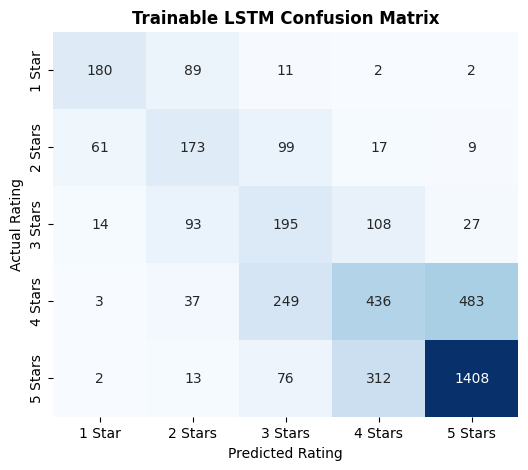

In [ ]:
target_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

# Store test accuracy and run evaluations for Trainable LSTM
lstm_probs = model_LSTM.predict(X_test_padded)
lstm_preds = np.argmax(lstm_probs, axis=1)
acc_lstm = accuracy_score(y_test, lstm_preds)

print("\n" + "="*60 + "\n EVALUATION: Trainable LSTM\n" + "="*60)
print(f"Test Accuracy: {acc_lstm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lstm_preds, target_names=target_labels))

#Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, lstm_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_labels, yticklabels=target_labels, cbar=False)
plt.title('Trainable LSTM Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Rating')
plt.xlabel('Predicted Rating')
plt.show()

Load GloVe Embeddings

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.7 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-100')
print("Download completed successfully!")

[==================================================] 100.0% 128.1/128.1MB downloaded
Download completed successfully!


In [ ]:
embedding_matrix = np.zeros((vocab_size, 100))
oov_count = 0

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        #check if the word exists in the loaded Gensim GloVe model
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
        else:
            #Out-of-Vocabulary (OOV)
            #handle words using random uniform distribution
            embedding_matrix[i] = np.random.uniform(-0.25, 0.25, 100)
            oov_count += 1

print(f"Embedding matrix successfully built with shape: {embedding_matrix.shape}")
print(f"Total out-of-vocabulary words initialized randomly: {oov_count}")

Embedding matrix successfully built with shape: (15000, 100)
Total out-of-vocabulary words initialized randomly: 2285


In [ ]:
epochs = 15
batch_size = 64
EMBEDDING_DIM = 100
num_classes = 5

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_Glove_LSTM = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False,
        name='frozen_glove_embeddings'
    ),

    LSTM(units=64,
         dropout=0.2,
         name='lstm_layer_m3'),

    Dense(units=num_classes, activation='softmax', name='output_layer')
], name="Model3_Glove_LSTM")

model_Glove_LSTM.build(input_shape=(None, max_sequence_len))

model_Glove_LSTM.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=["accuracy"]
)

model_Glove_LSTM.summary()

Model: "Model3_Glove_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frozen_glove_embeddings         │ (None, 263, 100)       │     1,500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_m3 (LSTM)            │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,542,565 (5.88 MB)

 Trainable params: 42,565 (166.27 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

Train GloVe LSTM

In [ ]:
history_Glove_LSTM = model_Glove_LSTM.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.10,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model_glove_lstm'),
    verbose=1
)

Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 88s 369ms/step - accuracy: 0.3145 - loss: 1.5122 - val_accuracy: 0.4470 - val_loss: 1.3111
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 140s 361ms/step - accuracy: 0.4438 - loss: 1.3053 - val_accuracy: 0.5152 - val_loss: 1.1305
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 359ms/step - accuracy: 0.4672 - loss: 1.2373 - val_accuracy: 0.5268 - val_loss: 1.0759
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 142s 360ms/step - accuracy: 0.4862 - loss: 1.1894 - val_accuracy: 0.4982 - val_loss: 1.1141
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 85s 370ms/step - accuracy: 0.5045 - loss: 1.1393 - val_accuracy: 0.4902 - val_loss: 1.0830
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 357ms/step - accuracy: 0.5228 - loss: 1.1006 - val_accuracy: 0.5134 - val_loss: 1.0752
Epoch 7/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 360ms/step - accuracy: 0.5254 - loss: 1.0763 - val_accuracy: 0.5701 - val_loss: 0.9422
Epoch 8/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 85s 369ms/step - accuracy: 0.5462 - loss:

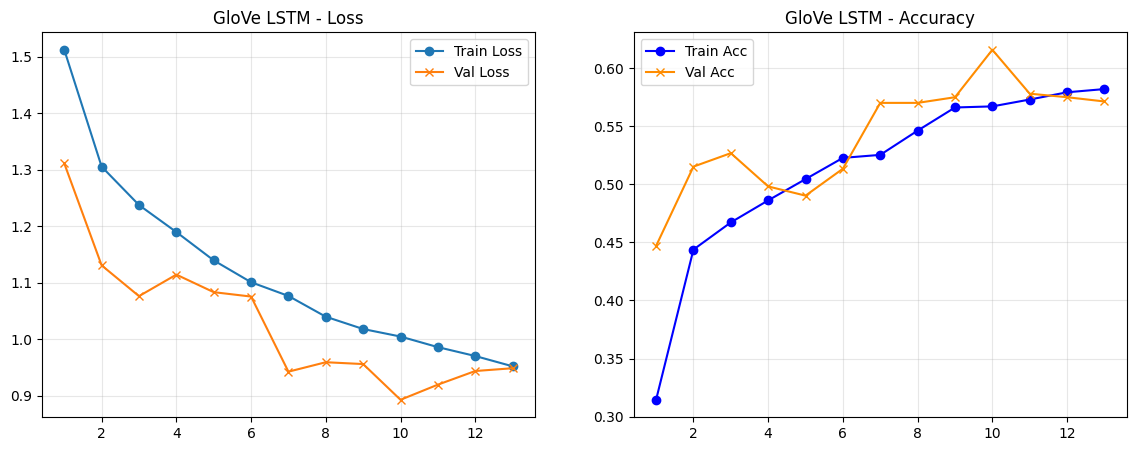

In [ ]:
curves(history_Glove_LSTM, "GloVe LSTM")

129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step

 EVALUATION: GloVe LSTM
Test Accuracy: 0.5840

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.66      0.69      0.67       284
     2 Stars       0.41      0.45      0.43       359
     3 Stars       0.32      0.36      0.34       437
     4 Stars       0.52      0.41      0.45      1208
     5 Stars       0.71      0.77      0.74      1811

    accuracy                           0.58      4099
   macro avg       0.52      0.53      0.53      4099
weighted avg       0.58      0.58      0.58      4099



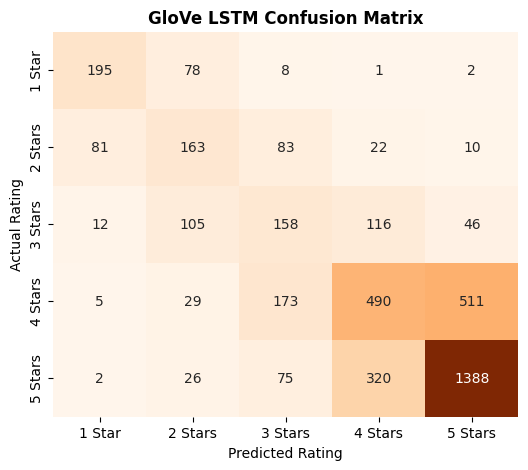

In [ ]:
glove_probs = model_Glove_LSTM.predict(X_test_padded)
glove_preds = np.argmax(glove_probs, axis=1)
acc_glove = accuracy_score(y_test, glove_preds)

print("\n" + "="*60 + f"\n EVALUATION: GloVe LSTM\n" + "="*60)
print(f"Test Accuracy: {acc_glove:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, glove_preds, target_names=target_labels))

# Render Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, glove_preds), annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_labels, yticklabels=target_labels, cbar=False)
plt.title('GloVe LSTM Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Rating')
plt.xlabel('Predicted Rating')
plt.show()

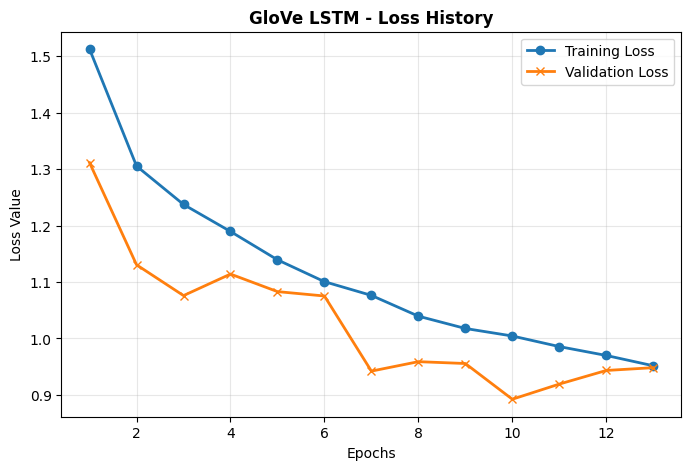

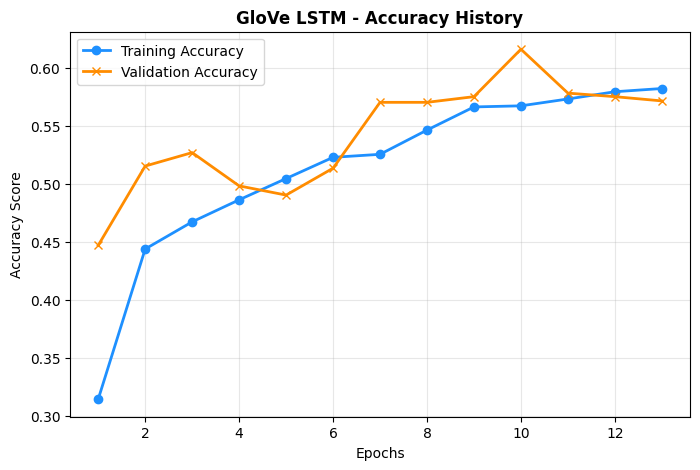

In [ ]:
epochs_range = range(1, len(history_Glove_LSTM.history['loss']) + 1)

#Loss History Chart
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_Glove_LSTM.history['loss'], label='Training Loss', marker='o', linewidth=2)
plt.plot(epochs_range, history_Glove_LSTM.history['val_loss'], label='Validation Loss', marker='x', linewidth=2)
plt.title('GloVe LSTM - Loss History', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Accuracy History Chart
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_Glove_LSTM.history['accuracy'], label='Training Accuracy', marker='o', linewidth=2, color='dodgerblue')
plt.plot(epochs_range, history_Glove_LSTM.history['val_accuracy'], label='Validation Accuracy', marker='x', linewidth=2, color='darkorange')
plt.title('GloVe LSTM - Accuracy History', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

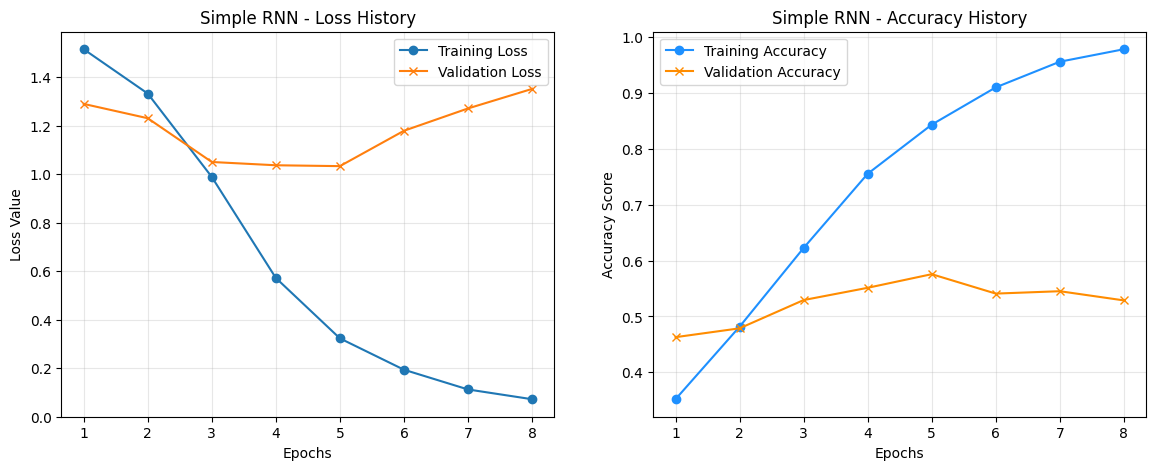

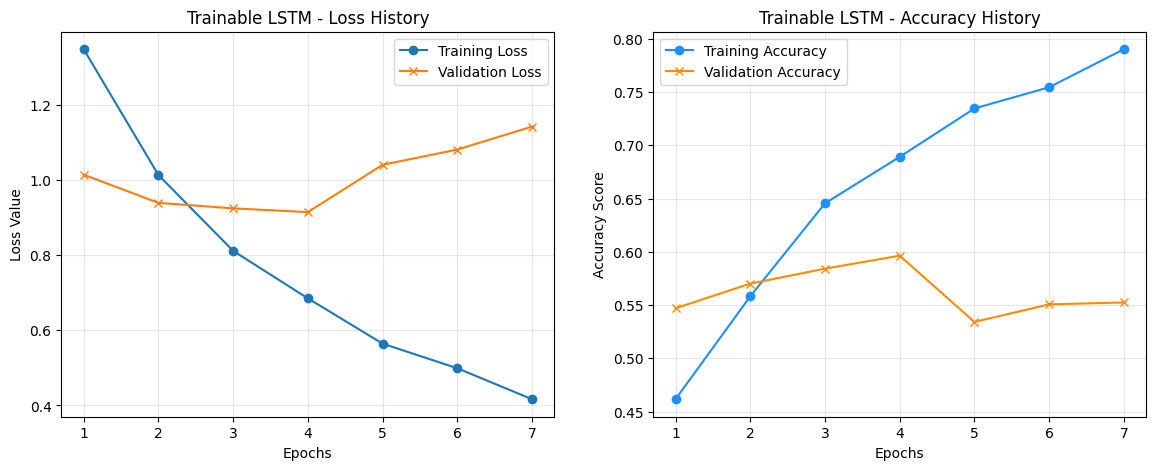

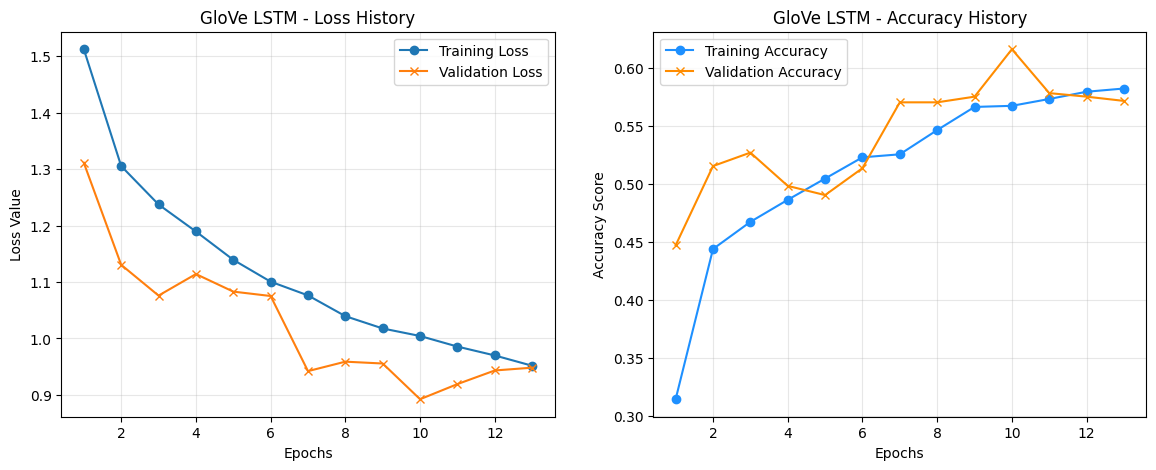

In [ ]:
def plot_history(history, title):
    epochs_range = range(1, len(history.history['loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    #Loss
    ax1.plot(epochs_range, history.history['loss'], label='Training Loss', marker='o')
    ax1.plot(epochs_range, history.history['val_loss'], label='Validation Loss', marker='x')
    ax1.set_title(f'{title} - Loss History')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss Value')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #Accuracy
    ax2.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', marker='o', color='dodgerblue')
    ax2.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', marker='x', color='darkorange')
    ax2.set_title(f'{title} - Accuracy History')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.show()

plot_history(history_RNN, "Simple RNN")
plot_history(history_LSTM, "Trainable LSTM")
plot_history(history_Glove_LSTM, "GloVe LSTM")

In [ ]:
import pickle

model_names = ['Simple RNN', 'Trainable LSTM', 'GloVe LSTM']
test_accuracies = [acc_rnn, acc_lstm, acc_glove]
models = [model_RNN, model_LSTM, model_Glove_LSTM]

#Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model Architecture': model_names,
    'Test Accuracy': test_accuracies
})
print("\n" + "="*45 + "\nMODEL ACCURACY COMPARISON (5-CLASS)\n" + "="*45)
print(comparison_df.to_string(index=False))

#best performing architecture identify
best_idx = np.argmax(test_accuracies)
best_model = models[best_idx]
best_model_name = model_names[best_idx]

print(f"\nBest Model selected: {best_model_name}")

best_model.save('best_hotel_model.keras')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Saved 'best_hotel_model.keras' and 'tokenizer.pkl' successfully.")


MODEL ACCURACY COMPARISON (5-CLASS)
Model Architecture  Test Accuracy
        Simple RNN       0.546231
    Trainable LSTM       0.583557
        GloVe LSTM       0.584045

Best Model selected: GloVe LSTM
Saved 'best_hotel_model.keras' and 'tokenizer.pkl' successfully.


In [ ]:
#get predictions for the best performing model
best_probs = best_model.predict(X_test_padded)
best_preds = np.argmax(best_probs, axis=1)

errors = np.where(y_test != best_preds)[0]
print(f"Total misclassifications in test split: {len(errors)}")

#3 examples of misclassifications on rating scales
for i, idx in enumerate(errors[:3]):
    original_idx = X_test_orig.index[idx]
    orig_text = df['Review'].loc[original_idx]

    actual_rating = y_test.iloc[idx] + 1
    predicted_rating = best_preds[idx] + 1

    print(f"\nExample {i+1}:")
    print(f"Original Text: {orig_text[:280]}...")
    print(f"Actual Rating: {actual_rating} Star(s) | Predicted: {predicted_rating} Star(s)")
    print("-" * 50)

129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step
Total misclassifications in test split: 1705

Example 1:
Original Text: great location nice staff mattresses soft, just 4 night stay early september hotel agora st. germaine, fabulous neighborhood great location, near metro stop shops boulangerie food kiosks ethnic food restaurants, internet cafes nearby, best hotel location, desk staff speaks englis...
Actual Rating: 3 Star(s) | Predicted: 4 Star(s)
--------------------------------------------------

Example 2:
Original Text: nice hotel nice hotel good area explore, arrival greated glass bubbly juice, arrived early room ready great, room road noisy night room quite hot sleep window open extremely noisy, bathroom okay water shower going not problem used towels reception bought towels quite quickly, roo...
Actual Rating: 3 Star(s) | Predicted: 5 Star(s)
--------------------------------------------------

Example 3:
Original Text: felt welcome location, location, location, wife stayed 1/8 1/13 ov

REAL-TIME PREDICTION GUI

In [ ]:
!pip install gradio -q
import gradio as gr

def predict_rating_gradio(review):
    if not review.strip():
        return "Please input review text.", "N/A"

    cleaned = clean_text_pipeline(review)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_sequence_len, padding='pre', truncating='pre')

    #predict
    probs = best_model.predict(padded)[0]
    class_idx = np.argmax(probs)
    rating = class_idx + 1
    confidence = probs[class_idx] * 100

    sentiment_labels = {
        1: "Very Poor",
        2: "Poor",
        3: "Neutral",
        4: "Good",
        5: "Excellent"
    }

    stars = "★" * rating + "☆" * (5 - rating)
    output_result = f"Rating: {stars} ({rating}/5 Stars) -> {sentiment_labels[rating]}"

    return output_result, f"{confidence:.2f}%"

#interface
interface = gr.Interface(
    fn=predict_rating_gradio,
    inputs=gr.Textbox(lines=5, placeholder="Enter a hotel review here...", label="User Review"),
    outputs=[
        gr.Textbox(label="Predicted Rating & Sentiment"),
        gr.Textbox(label="Model Confidence Score")
    ],
    title="Real-Time Hotel Review Rating Estimator (1-5 Stars)",
    description="Uses our trained Deep Learning model to predict rating scores.",
    theme="soft"
)

interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://87f84e78ce398e44a4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ★